# <div align="center"><u>The NNG-GS dataset</u>

## - General description of the NNG-GS dataset:
    
The following implementation applies an NNG-GS implementation to the Colon-Kidney dataset, where the dimensionality ranges between 55 and 110 features (gene expressions).

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
from sklearn import metrics

from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csr_matrix

import networkx as nx

import time

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the final colon-kidney dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv")

# Print the dataset
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Exclude last 2 columns (Targets)

In [5]:
# Exclude the last two columns
df_excluded = df.iloc[:, :-2]

df_excluded

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,2386.3,2035.7,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,1225.7,3811.6,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,5114.2,17154.4,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,4579.8,12382.2,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,5666.9,13321.1,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1425.0,1752.1,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,1663.2,5334.5,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1145.6,1511.6,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,2280.7,7192.6,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6


### Step 1: Construct the graph and the graph signal 

### Store the dataset in an array

In [6]:
# Load the dataset in an array
# Rows = patients/samples, Columns = genes/features
X = df_excluded.iloc[:, :-2].values  # Shape: (546, 10935)

### Set number of patients and k value

In [7]:
# Number of samples
num_patients = X.shape[0]

# Set the number of nearest neighbors (as per the paper, use k=3)
k = 3

### Step 1.1: Compute correlation matrix between patients

In [8]:
# Correlation is computed between rows (samples)
# So we center the data row-wise and compute cosine similarity
X_centered = X - X.mean(axis=1, keepdims=True)
corr_matrix = np.corrcoef(X_centered)

# Make sure correlation matrix is symmetric and set diagonals to 0
np.fill_diagonal(corr_matrix, 0)

print(corr_matrix)

[[0.         0.77146968 0.91653524 ... 0.83643027 0.86995995 0.85987651]
 [0.77146968 0.         0.7051295  ... 0.7149052  0.7262535  0.73320013]
 [0.91653524 0.7051295  0.         ... 0.78748933 0.84025803 0.82624752]
 ...
 [0.83643027 0.7149052  0.78748933 ... 0.         0.95580252 0.89641406]
 [0.86995995 0.7262535  0.84025803 ... 0.95580252 0.         0.92978989]
 [0.85987651 0.73320013 0.82624752 ... 0.89641406 0.92978989 0.        ]]


### Step 1.2: Build k-nearest neighbors graph from correlation matrix

In [9]:
# Build k-nearest neighbors graph from correlation matrix

# For each patient, keep only the top-k correlations (neighbors)
adj_matrix = np.zeros((num_patients, num_patients))

for i in range(num_patients):
    # Get indices of top k correlated patients
    neighbors = np.argsort(corr_matrix[i])[-k:]
    adj_matrix[i, neighbors] = 1

# Make the graph undirected by symmetrizing the adjacency matrix
adj_matrix = np.maximum(adj_matrix, adj_matrix.T)

print(adj_matrix)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Step 1.3: Construct the degree matrix

In [10]:
# Construct the degree matrix
degree_matrix = np.diag(np.sum(adj_matrix, axis=1))

print(degree_matrix)

[[6. 0. 0. ... 0. 0. 0.]
 [0. 3. 0. ... 0. 0. 0.]
 [0. 0. 3. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 3. 0. 0.]
 [0. 0. 0. ... 0. 8. 0.]
 [0. 0. 0. ... 0. 0. 3.]]


### Step 1.4: Compute the Laplacian matrix

In [11]:
# Compute the Laplacian matrix
laplacian_matrix = degree_matrix - adj_matrix

print(laplacian_matrix)

[[ 6.  0.  0. ...  0.  0.  0.]
 [ 0.  3.  0. ...  0.  0.  0.]
 [ 0.  0.  3. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  3. -1.  0.]
 [ 0.  0.  0. ... -1.  8.  0.]
 [ 0.  0.  0. ...  0.  0.  3.]]


### Step 2: Select significant genes

### Set d - number of genes to select + helping variables

In [12]:
# d: number of genes to select (filtered dimension)

d = 100

# Helping variables
num_genes = X.shape[1]
result = np.zeros(num_genes)

### Step 2.1: Compute X_l^T L X_l for each gene

In [13]:
# Gene Selection based on Laplacian quadratic form
for l in range(num_genes):
    gene_signal = X[:, l]  # expression of gene l across patients (M,)
    result[l] = gene_signal.T @ laplacian_matrix @ gene_signal # compute X_l^T L X_l

### Step 2.2: Sort genes by descending order and select d most significant

In [14]:
# Sort genes by descending order of result
sorted_indices = np.argsort(-result)  # descending

# Select top d genes
selected_indices = sorted_indices[:d]

### Step 2.3: Construct filtered gene expressions matrix Y (M x d)

In [15]:
# Construct Filtered gene expressions matrix Y (M x d)
Y = X[:, selected_indices]

print("Selected gene indices:", selected_indices)

Selected gene indices: [10894 10930    47    48  8168    53 10931    49  8167    51    50  6311
 10886 10887  6094  3586  4770  9455  5400  5134  7469  4091  7476  5437
  6246  5711  1143  4388  8364  4924  6266  5833  6219  4427  2921  1486
   245  1481  3405  6128  5945   201  7524  3881  1004  3887  5671  5998
  6084   143  3777  1081  5533  1204  5186  3733  9007  5392   741   579
  4852  4489   746   560   995  1192  9016   586  4744  6254  6253  4831
  5702   663  5791  6396  1804  4580  4047  8234   632  4844  6401   356
   977  5650  2518  4619  5813 10895  2204  5291  4111   845  4862  4808
  5619  8228  6354  5231]


### Plot 4 graph signals to visualize the results

C:\Users\user\anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


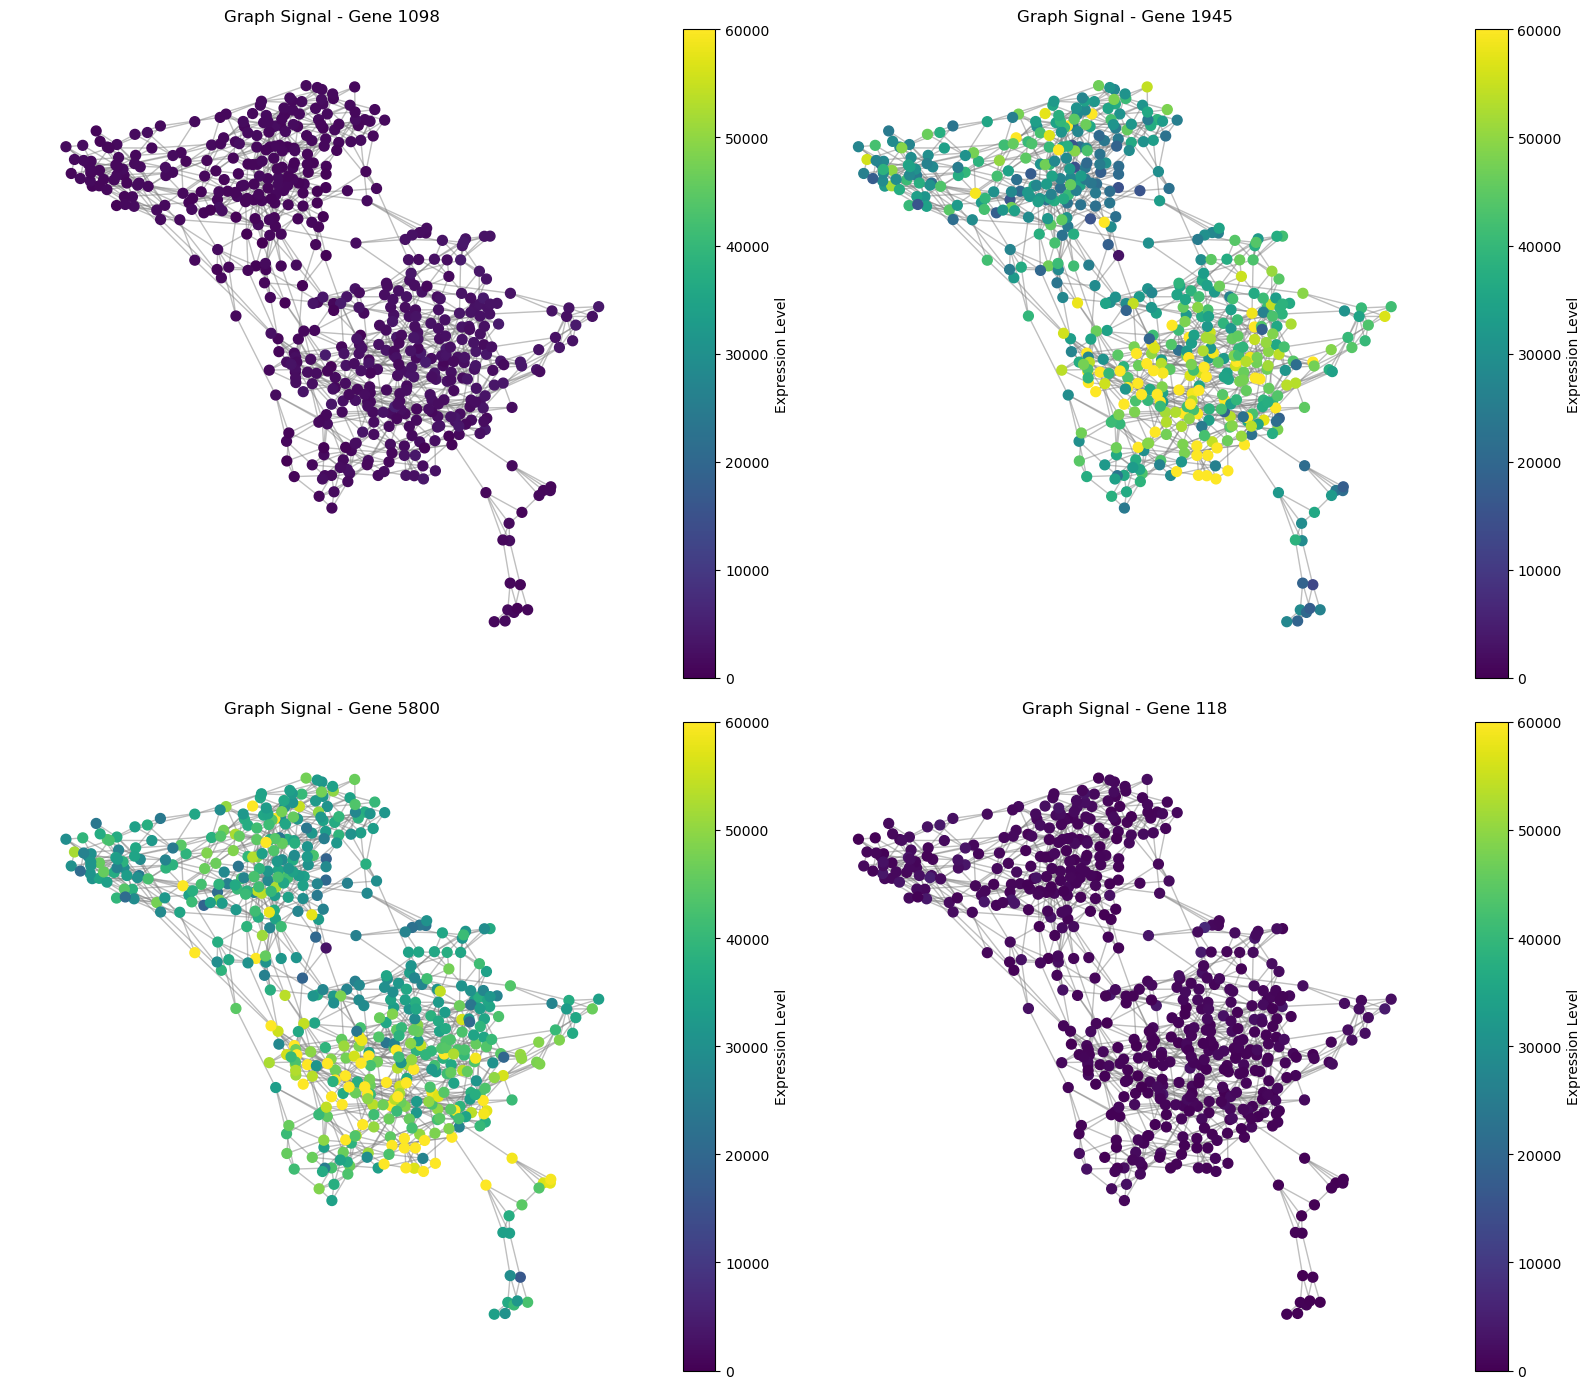

In [16]:
# Use specific gene indices (assumed to be 0-based already)
specific_genes = [1098, 1945, 5800, 118]

# Create graph from adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Use consistent layout for all plots
pos = nx.spring_layout(G, seed=42)

# Shared normalization for all plots (0 to 60,000)
norm = plt.Normalize(vmin=0, vmax=60000)

# Setup 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, gene_idx in enumerate(specific_genes):
    gene_expression = X[:, gene_idx]
    node_colors = plt.cm.viridis(norm(gene_expression))
    
    ax = axes[i]
    ax.set_title(f"Graph Signal - Gene {gene_idx}")
    ax.axis('off')
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, edge_color='gray')
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap='viridis', node_size=50, ax=ax)

    # Individual colorbar for each subplot
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Expression Level")

plt.tight_layout()
plt.show()

### Construct the NNG-GS dataset 

### Store only the selected columns in the dataframe

In [17]:
# Get all column indices
all_indices = list(range(df.shape[1]))

# Get indices to drop = all except selected
drop_indices = [i for i in all_indices if i not in selected_indices and i < df.shape[1] - 2]

# Drop those columns
selected_df = df.drop(df.columns[drop_indices], axis=1)

df = selected_df

df

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1555653_at,1556499_s_at,1558678_s_at,200003_s_at,...,226147_s_at,227404_s_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,48695.9,6341.0,30432.1,46503.7,...,182.2,8354.3,64127.8,59227.1,90722.5,49946.3,85830.1,57084.9,0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,25368.1,19004.0,28030.0,29198.2,...,378.8,11515.7,33593.3,28815.0,54776.9,54811.3,53322.5,37139.5,0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,72650.6,15652.5,20290.1,46739.0,...,281.5,11475.4,127790.6,108451.5,214034.7,62308.8,203060.6,146422.6,0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,75596.0,43916.5,43874.5,53118.7,...,26.2,41609.1,98447.0,90216.3,112892.8,69876.5,119460.8,95682.3,0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,83284.8,35598.6,51670.3,45815.7,...,106.5,54012.0,131028.8,118324.1,191001.4,80397.2,178178.2,129533.2,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,29272.7,43172.3,12649.0,60428.7,...,10927.8,20796.1,46628.6,42320.0,74103.6,45601.3,65246.8,46710.2,1,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,20338.2,70094.8,24209.6,54951.0,...,7500.7,32477.4,60248.2,46485.4,106527.6,51837.2,80607.7,60204.9,1,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,33890.7,13787.4,6814.2,52274.5,...,24002.9,6702.8,38609.1,32498.5,67663.2,40467.4,56065.6,43347.8,1,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,52147.5,32273.1,40512.7,58638.3,...,38134.8,13638.6,65646.3,57327.1,105755.9,57172.0,89215.2,71290.1,1,Colon


### Export the NNG-GS dataset to .csv file

In [18]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\NNG-GS\The colon-kidney NNG-GS filtered dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\NNG-GS\The colon-kidney NNG-GS filtered dataset.csv


### Transform outliers

In [19]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [20]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1555653_at,1556499_s_at,1558678_s_at,200003_s_at,...,226147_s_at,227404_s_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,48695.9,6341.0,30432.1,46503.7,...,182.2,8354.3,64127.8,59227.1,90722.5,49946.3,85830.1,57084.9,0.0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,25368.1,19004.0,28030.0,29198.2,...,378.8,11515.7,33593.3,28815.0,54776.9,54811.3,53322.5,37139.5,0.0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,72650.6,15652.5,20290.1,46739.0,...,281.5,11475.4,127790.6,108451.5,214034.7,62308.8,203060.6,146422.6,0.0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,75596.0,43916.5,43874.5,53118.7,...,26.2,41609.1,98447.0,90216.3,112892.8,69876.5,119460.8,95682.3,0.0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,83284.8,35598.6,51670.3,45815.7,...,106.5,54012.0,131028.8,118324.1,191001.4,80397.2,178178.2,129533.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,29272.7,43172.3,12649.0,60428.7,...,10927.8,20796.1,46628.6,42320.0,74103.6,45601.3,65246.8,46710.2,1.0,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,20338.2,70094.8,24209.6,54951.0,...,7500.7,32477.4,60248.2,46485.4,106527.6,51837.2,80607.7,60204.9,1.0,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,33890.7,13787.4,6814.2,52274.5,...,24002.9,6702.8,38609.1,32498.5,67663.2,40467.4,56065.6,43347.8,1.0,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,52147.5,32273.1,40512.7,58638.3,...,38134.8,13638.6,65646.3,57327.1,105755.9,57172.0,89215.2,71290.1,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [21]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 1497


### Export the dataset to .csv file

In [22]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\NNG-GS\The colon-kidney NNG-GS filtered capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\NNG-GS\The colon-kidney NNG-GS filtered capped dataset.csv


### End time

In [23]:
# End time
end_time = time.time()

### Elapsed time

In [24]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for NNG-GS Dataset: {elapsed_time:.2f} seconds")

Elapsed time for High Pearson Correlation Dataset: 6.85 seconds
